In [2]:
import ollama
from pathlib import Path

MODEL_NAME = "qwen3-vl:4b-instruct"
IMAGE_DIR = Path("ocr데이터/vehicle_number")
PROMPT = "이 이미지는 차량 번호판이다. 번호판에 적힌 문자와 숫자를 그대로 읽어서 출력해줘. 다른 설명은 하지 말고 번호판 텍스트만 출력해."

image_paths = sorted(IMAGE_DIR.glob("*.jpg"))

ocr_results = []  # {"file": 파일명, "output": 모델 원본 출력}
for image_path in image_paths:
    response = ollama.chat(
        model=MODEL_NAME,
        messages=[
            {
                "role": "user",
                "content": PROMPT,
                "images": [str(image_path)],
            }
        ],
    )
    result_text = response["message"]["content"].strip()
    print(f"{image_path.name} -> {result_text}")
    ocr_results.append({"file": image_path.name, "output": result_text})


263나6131.jpg -> 263U6131
27더1043.jpg -> 27더1043
29더2115.jpg -> 29대 2115
31루0325.jpg -> 31루 0325
40너8801.jpg -> 404 8801
43모8778.jpg -> 432 8778
45소3404.jpg -> 45소 3404
46루5499.jpg -> 46루 5499
46주6121.jpg -> 46주 6121
49가7438.jpg -> 49π 7438
52조0374.jpg -> 52조 0374
58호0205-3.jpg -> 58호 0205
69주3568.jpg -> 69주 3568
72두2779.jpg -> 72号 2779
81나7295.jpg -> 8147295
87보6150-35.jpg -> 87보6150
경기37바1743-27.jpg -> 위37바1743
경기37바2126-27.jpg -> 경37배 2126
경기37바5193-7.jpg -> 국37바5193
경기37바5300-3.jpg -> 경37배5300
경기92바6611-36.jpg -> 경기92바6611
경기94자4581.jpg -> 경94자4581
서울31사1369-2.jpg -> 설31사1369


In [3]:
import re

# 파일명(정답)/모델 출력 정제용 유틸
CLEAN_PATTERN = re.compile(r"[^0-9A-Za-z가-힣]")
TRAILING_INDEX_PATTERN = re.compile(r"-\d+$")
# 번호판 형식: (지역명, 선택)(앞자리 2~3자리 숫자)(한글 1자)(뒷자리 4자리 숫자)
PLATE_PATTERN = re.compile(r"(?:(?P<region>[가-힣]{2,}))?(?P<front>\d{2,3})(?P<kor>[가-힣])(?P<back>\d{4})")


def clean(text: str) -> str:
    """숫자/영문/한글만 남기고 나머지(공백, 특수토큰, 문장부호 등) 제거."""
    return CLEAN_PATTERN.sub("", text)


def ground_truth_from_filename(stem: str) -> str:
    """'58호0205-3' -> '58호0205' 처럼 끝의 중복 촬영 인덱스를 제거한 정답 문자열."""
    return TRAILING_INDEX_PATTERN.sub("", stem)


def parse_plate(text: str):
    """정제된 문자열에서 번호판 형식(지역/앞자리/한글/뒷자리)을 찾아 dict로 반환. 매치 실패 시 None."""
    match = PLATE_PATTERN.search(text)
    if not match:
        return None
    return {
        "region": match.group("region") or "",
        "front": match.group("front"),
        "kor": match.group("kor"),
        "back": match.group("back"),
    }


def edit_distance(a: str, b: str) -> int:
    if a == b:
        return 0
    if not a:
        return len(b)
    if not b:
        return len(a)

    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        curr = [i] + [0] * len(b)
        for j, cb in enumerate(b, start=1):
            cost = 0 if ca == cb else 1
            curr[j] = min(
                prev[j] + 1,        # 삭제
                curr[j - 1] + 1,    # 삽입
                prev[j - 1] + cost,  # 치환
            )
        prev = curr
    return prev[-1]


def best_match_distance(cleaned_output: str, ground_truth: str) -> int:
    """정답 길이 -2~+2 범위의 모든 부분 문자열 중 편집거리가 가장 작은 값을 찾는다."""
    gt_len = len(ground_truth)
    if not cleaned_output:
        return gt_len

    best = edit_distance(cleaned_output, ground_truth)
    for window in range(max(1, gt_len - 2), gt_len + 3):
        for start in range(0, max(1, len(cleaned_output) - window + 1)):
            candidate = cleaned_output[start:start + window]
            dist = edit_distance(candidate, ground_truth)
            if dist < best:
                best = dist
    return best

In [4]:
# 완전 일치율(Exact Match) + CER(문자 오류율) 평가
eval_rows = []
for row in ocr_results:
    stem = Path(row["file"]).stem
    ground_truth = ground_truth_from_filename(stem)
    cleaned_output = clean(row["output"])

    dist = best_match_distance(cleaned_output, ground_truth)
    cer = dist / len(ground_truth) if ground_truth else 0.0
    exact_match = ground_truth.lower() in cleaned_output.lower()

    eval_rows.append(
        {
            "file": row["file"],
            "ground_truth": ground_truth,
            "output": row["output"],
            "cleaned_output": cleaned_output,
            "cer": round(cer, 3),
            "exact_match": exact_match,
        }
    )

header = f"{'파일명':<22}{'정답':<12}{'정제된 출력':<20}{'CER':<8}{'완전일치'}"
print(header)
print("-" * len(header))
for r in eval_rows:
    print(f"{r['file']:<22}{r['ground_truth']:<12}{r['cleaned_output'][:18]:<20}{r['cer']:<8}{'O' if r['exact_match'] else 'X'}")

total = len(eval_rows)
avg_cer = sum(r["cer"] for r in eval_rows) / total
exact_rate = sum(r["exact_match"] for r in eval_rows) / total
print(f"\n총 이미지 수: {total}")
print(f"평균 CER: {avg_cer:.3f}")
print(f"완전 일치율: {exact_rate:.1%}")


파일명                   정답          정제된 출력              CER     완전일치
------------------------------------------------------------------
263나6131.jpg          263나6131    263U6131            0.125   X
27더1043.jpg           27더1043     27더1043             0.0     O
29더2115.jpg           29더2115     29대2115             0.143   X
31루0325.jpg           31루0325     31루0325             0.0     O
40너8801.jpg           40너8801     4048801             0.143   X
43모8778.jpg           43모8778     4328778             0.143   X
45소3404.jpg           45소3404     45소3404             0.0     O
46루5499.jpg           46루5499     46루5499             0.0     O
46주6121.jpg           46주6121     46주6121             0.0     O
49가7438.jpg           49가7438     497438              0.143   X
52조0374.jpg           52조0374     52조0374             0.0     O
58호0205-3.jpg         58호0205     58호0205             0.0     O
69주3568.jpg           69주3568     69주3568             0.0     O
72두2779.jpg           72두2779     

In [5]:
# 필드 단위 정확도 평가 (지역 / 앞자리 숫자 / 한글 문자 / 뒷자리 숫자)
field_names = ["region", "front", "kor", "back"]
field_total = {f: 0 for f in field_names}
field_correct = {f: 0 for f in field_names}

field_rows = []
for r in eval_rows:
    gt_fields = parse_plate(r["ground_truth"])
    out_fields = parse_plate(r["cleaned_output"])

    row_result = {"file": r["file"]}
    for f in field_names:
        gt_value = gt_fields[f] if gt_fields else ""
        if f == "region" and not gt_value:
            # 정답 자체에 지역명이 없는 번호판은 region 필드 채점에서 제외
            row_result[f] = "-"
            continue

        field_total[f] += 1
        out_value = out_fields[f] if out_fields else ""
        is_correct = gt_value == out_value
        field_correct[f] += int(is_correct)
        row_result[f] = f"{out_value or '(없음)'} ({'O' if is_correct else 'X'})"

    field_rows.append(row_result)

header = f"{'파일명':<22}{'region':<18}{'front':<12}{'kor':<10}{'back':<14}"
print(header)
print("-" * len(header))
for row in field_rows:
    print(f"{row['file']:<22}{row['region']:<18}{row['front']:<12}{row['kor']:<10}{row['back']:<14}")

print("\n=== 필드별 정확도 ===")
field_label = {"region": "지역명", "front": "앞자리 숫자", "kor": "한글 문자", "back": "뒷자리 숫자"}
for f in field_names:
    if field_total[f] == 0:
        continue
    acc = field_correct[f] / field_total[f]
    print(f"{field_label[f]:<10}: {field_correct[f]}/{field_total[f]} ({acc:.1%})")


파일명                   region            front       kor       back          
----------------------------------------------------------------------------
263나6131.jpg          -                 (없음) (X)    (없음) (X)  (없음) (X)      
27더1043.jpg           -                 27 (O)      더 (O)     1043 (O)      
29더2115.jpg           -                 29 (O)      대 (X)     2115 (O)      
31루0325.jpg           -                 31 (O)      루 (O)     0325 (O)      
40너8801.jpg           -                 (없음) (X)    (없음) (X)  (없음) (X)      
43모8778.jpg           -                 (없음) (X)    (없음) (X)  (없음) (X)      
45소3404.jpg           -                 45 (O)      소 (O)     3404 (O)      
46루5499.jpg           -                 46 (O)      루 (O)     5499 (O)      
46주6121.jpg           -                 46 (O)      주 (O)     6121 (O)      
49가7438.jpg           -                 (없음) (X)    (없음) (X)  (없음) (X)      
52조0374.jpg           -                 52 (O)      조 (O)     0374 (O)      

주된 약점은 숫자가 아니라 한글 글자 인식입니다. 구체적으로 3가지 패턴이 보입니다.

1. 한글을 아예 못 읽고 다른 문자로 대체 → 번호판 구조 자체가 붕괴 (6/23건)
- 263나6131→263U6131(로마자 U)
- 49가7438→497438(π를 잘못 읽고 정제 과정에서 삭제됨)
- 72두2779→722779(한자 号로 오인식 후 삭제)
- 81나7295→8147295

이 경우 한글 자리 자체가 사라지거나 한글이 아닌 문자로 나와서 정규식 파싱이 아예 실패하고, 앞/뒤 숫자까지 "없음" 처리됩니다. 즉 필드 정확도 표의 숫자 오류 대부분은 사실 숫자를 잘못 읽은 게 아니라 한글 인식 실패가 번호판 전체를 망가뜨린 연쇄 효과입니다.

2. 모양이 비슷한 한글끼리 혼동 (3건)
- 더→대
- 바→배(2번). 

획 하나 차이인 글자들에서 발생 — 해상도/선명도 문제일 가능성이 높습니다.

3. 2글자 지역명 인식이 특히 취약 (1/7건)

대부분 두 글자 중 한 글자만 읽히거나(경기→경) 완전히 다른 한 글자로 대체됨(경기→위, 국, 설). 지역명은 번호판에서 상대적으로 작은 글씨로 찍히는 경우가 많아 취약한 것으로 보입니다.

한 번 해상도를 올려 보도록 하겠습니다.

파일: 263나6131.jpg
원본 크기: (438, 154)
업스케일 크기: (876, 308)


C:\Users\rando\AppData\Local\Temp\ipykernel_25404\3436921718.py:36: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\rando\AppData\Local\Temp\ipykernel_25404\3436921718.py:36: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\rando\AppData\Local\Temp\ipykernel_25404\3436921718.py:36: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\rando\AppData\Local\Temp\ipykernel_25404\3436921718.py:36: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\rando\AppData\Local\Temp\ipykernel_25404\3436921718.py:36: UserWarning: Glyph 52992 (\N{HANGUL SYLLABLE KE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\rando\AppData\Local\Temp\ipykernel_25404\3436921718.py:36: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from

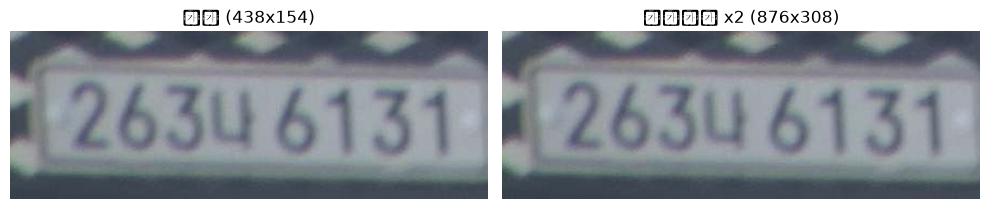

In [14]:
# 업스케일 전/후 샘플 비교
import io
from PIL import Image
import matplotlib.pyplot as plt

UPSCALE_FACTOR = 2


def upscale_image(path: Path, factor: int = UPSCALE_FACTOR) -> Image.Image:
    img = Image.open(path)
    new_size = (img.width * factor, img.height * factor)
    return img.resize(new_size, Image.LANCZOS)


def image_to_bytes(img: Image.Image) -> bytes:
    buf = io.BytesIO()
    img.convert("RGB").save(buf, format="JPEG")
    return buf.getvalue()


sample_path = image_paths[0]
original_img = Image.open(sample_path)
upscaled_img = upscale_image(sample_path)

print(f"파일: {sample_path.name}")
print(f"원본 크기: {original_img.size}")
print(f"업스케일 크기: {upscaled_img.size}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(original_img)
axes[0].set_title(f"원본 ({original_img.width}x{original_img.height})")
axes[0].axis("off")
axes[1].imshow(upscaled_img)
axes[1].set_title(f"업스케일 x{UPSCALE_FACTOR} ({upscaled_img.width}x{upscaled_img.height})")
axes[1].axis("off")
plt.tight_layout()
plt.show()


In [15]:
# 업스케일한 이미지로 동일하게 OCR 실행 후, 업스케일 전/후 정확도 비교
ocr_results_upscaled = []
for image_path in image_paths:
    img_bytes = image_to_bytes(upscale_image(image_path))
    response = ollama.chat(
        model=MODEL_NAME,
        messages=[
            {
                "role": "user",
                "content": PROMPT,
                "images": [img_bytes],
            }
        ],
    )
    result_text = response["message"]["content"].strip()
    ocr_results_upscaled.append({"file": image_path.name, "output": result_text})


def evaluate(results):
    rows = []
    for row in results:
        stem = Path(row["file"]).stem
        ground_truth = ground_truth_from_filename(stem)
        cleaned_output = clean(row["output"])

        dist = best_match_distance(cleaned_output, ground_truth)
        cer = dist / len(ground_truth) if ground_truth else 0.0
        exact_match = ground_truth.lower() in cleaned_output.lower()

        rows.append(
            {
                "file": row["file"],
                "ground_truth": ground_truth,
                "cleaned_output": cleaned_output,
                "cer": round(cer, 3),
                "exact_match": exact_match,
            }
        )
    return rows


def field_accuracy(rows):
    field_names = ["region", "front", "kor", "back"]
    total = {f: 0 for f in field_names}
    correct = {f: 0 for f in field_names}
    for r in rows:
        gt_fields = parse_plate(r["ground_truth"])
        out_fields = parse_plate(r["cleaned_output"])
        for f in field_names:
            gt_value = gt_fields[f] if gt_fields else ""
            if f == "region" and not gt_value:
                continue
            total[f] += 1
            out_value = out_fields[f] if out_fields else ""
            correct[f] += int(gt_value == out_value)
    return {f: (correct[f] / total[f] if total[f] else 0.0) for f in field_names}, total


eval_rows_upscaled = evaluate(ocr_results_upscaled)
field_acc_before, field_total_before = field_accuracy(eval_rows)
field_acc_after, field_total_after = field_accuracy(eval_rows_upscaled)

total = len(eval_rows)
avg_cer_before = sum(r["cer"] for r in eval_rows) / total
avg_cer_after = sum(r["cer"] for r in eval_rows_upscaled) / total
exact_rate_before = sum(r["exact_match"] for r in eval_rows) / total
exact_rate_after = sum(r["exact_match"] for r in eval_rows_upscaled) / total

print("=== 업스케일 전/후 정확도 비교 ===")
print(f"{'지표':<14}{'업스케일 전':<14}{'업스케일 후':<14}")
print("-" * 42)
print(f"{'평균 CER':<14}{avg_cer_before:<14.3f}{avg_cer_after:<14.3f}")
print(f"{'완전 일치율':<14}{exact_rate_before:<14.1%}{exact_rate_after:<14.1%}")

field_label = {"region": "지역명", "front": "앞자리 숫자", "kor": "한글 문자", "back": "뒷자리 숫자"}
print()
for f in ["region", "front", "kor", "back"]:
    if field_total_before[f] == 0:
        continue
    print(f"{field_label[f]:<14}{field_acc_before[f]:<14.1%}{field_acc_after[f]:<14.1%}")


=== 업스케일 전/후 정확도 비교 ===
지표            업스케일 전        업스케일 후        
------------------------------------------
평균 CER        0.096         0.108         
완전 일치율        43.5%         34.8%         

지역명           14.3%         14.3%         
앞자리 숫자        73.9%         69.6%         
한글 문자         60.9%         56.5%         
뒷자리 숫자        73.9%         69.6%         


오히려 떨어짐!

LLM에게 정확도 출력해 달라고 부탁해 보기

In [12]:
# 모델 자체 확신도(confidence) 요청 + 실제 정확도와 비교
import json

CONFIDENCE_PROMPT = (
    "이 이미지는 차량 번호판이다. 번호판에 적힌 문자와 숫자를 읽어라.\n"
    "다음 JSON 형식으로만 답변하고 다른 설명은 하지 마라.\n"
    '{"text": "번호판 텍스트", "confidence": 0~100 사이의 정수 확신도}'
)


def parse_confidence_response(raw: str):
    """모델 출력에서 JSON을 파싱. 코드블록(```json ... ```)이 섞여 있으면 벗겨낸다."""
    text = raw.strip()
    if text.startswith("```"):
        text = text.strip("`")
        text = text.split("\n", 1)[-1] if "\n" in text else text
        text = text.rsplit("```", 1)[0]
    try:
        data = json.loads(text)
        return str(data.get("text", "")), int(data.get("confidence", 0))
    except (json.JSONDecodeError, ValueError, TypeError):
        return raw, None


confidence_rows = []
for image_path in image_paths:
    response = ollama.chat(
        model=MODEL_NAME,
        messages=[
            {
                "role": "user",
                "content": CONFIDENCE_PROMPT,
                "images": [str(image_path)],
            }
        ],
    )
    output_text, confidence = parse_confidence_response(response["message"]["content"])

    stem = image_path.stem
    ground_truth = ground_truth_from_filename(stem)
    cleaned_output = clean(output_text)
    dist = best_match_distance(cleaned_output, ground_truth)
    cer = dist / len(ground_truth) if ground_truth else 0.0
    exact_match = ground_truth.lower() in cleaned_output.lower()

    confidence_rows.append(
        {
            "file": image_path.name,
            "ground_truth": ground_truth,
            "cleaned_output": cleaned_output,
            "confidence": confidence,
            "cer": round(cer, 3),
            "exact_match": exact_match,
        }
    )

header = f"{'파일명':<22}{'정답':<12}{'출력':<14}{'확신도':<8}{'실제CER':<10}{'실제일치'}"
print(header)
print("-" * len(header))
for r in confidence_rows:
    conf_str = f"{r['confidence']}%" if r["confidence"] is not None else "파싱실패"
    print(f"{r['file']:<22}{r['ground_truth']:<12}{r['cleaned_output']:<14}{conf_str:<8}{r['cer']:<10}{'O' if r['exact_match'] else 'X'}")

# 확신도가 실제 정확도와 얼마나 일치하는지(캘리브레이션) 확인
valid_rows = [r for r in confidence_rows if r["confidence"] is not None]
correct_confidences = [r["confidence"] for r in valid_rows if r["exact_match"]]
wrong_confidences = [r["confidence"] for r in valid_rows if not r["exact_match"]]

print("\n=== 확신도 캘리브레이션 ===")
if correct_confidences:
    print(f"실제로 맞춘 케이스 평균 확신도: {sum(correct_confidences) / len(correct_confidences):.1f}%")
if wrong_confidences:
    print(f"실제로 틀린 케이스 평균 확신도: {sum(wrong_confidences) / len(wrong_confidences):.1f}%")


파일명                   정답          출력            확신도     실제CER     실제일치
----------------------------------------------------------------------
263나6131.jpg          263나6131    263u6131      85%     0.125     X
27더1043.jpg           27더1043     27더1043       95%     0.0       O
29더2115.jpg           29더2115     29대2115       95%     0.143     X
31루0325.jpg           31루0325     31루0325       95%     0.0       O
40너8801.jpg           40너8801     4048801       95%     0.143     X
43모8778.jpg           43모8778     4328778       90%     0.143     X
45소3404.jpg           45소3404     45소3404       95%     0.0       O
46루5499.jpg           46루5499     46부5499       95%     0.143     X
46주6121.jpg           46주6121     46주6121       85%     0.0       O
49가7438.jpg           49가7438     497438        95%     0.143     X
52조0374.jpg           52조0374     52조0374       95%     0.0       O
58호0205-3.jpg         58호0205     58오0205       95%     0.143     X
69주3568.jpg           69주3568     69주3568 

별로 의미 없음!

이번엔 LLM에게 번호판과 관련된 정보들을 제공하고 맞춰 보도록 합시다.

In [19]:
# 번호판 후보 목록(지역명 / 가운데 한글)을 프롬프트에 제공해서 1차 결과를 재검토시키기
REGION_NAMES = [
    "서울", "부산", "대구", "인천", "광주", "대전", "울산", "세종",
    "경기", "강원", "충북", "충남", "전북", "전남", "경북", "경남", "제주",
]

# 1차 결과를 "정답"처럼 그대로 박아넣으면 모델이 새로 판독하지 않고 베껴 쓰는 경향(anchoring)이 있어서,
# 참고용임을 명시하고 이미지 근거로 다시 판단하라고 명시적으로 지시한다.
CORRECTION_PROMPT_TEMPLATE = (
    "이것은 한국 자동차 번호판 이미지이므로 숫자와 한글 문자만 사용할 것.\n"
    "번호판의 문자를 그대로 텍스트로 옮길 것.\n"
    "일반적으로 한국의 자동차 번호판은 아래와 같은 형태를 띤다.\n"
    "[87나2135, 경기36바5142]\n"
    "번호판 앞에 지역명이 있다면 반드시 다음 목록 중 하나다: {region_list}\n"
    "다음 JSON 형식으로만 답하고 다른 설명은 하지 마라.\n"
    '{{"text": "번호판 텍스트"}}'
)


def parse_text_response(raw: str) -> str:
    """모델 출력에서 JSON의 text 필드를 파싱. 실패하면 원문 그대로 반환."""
    text = raw.strip()
    if text.startswith("```"):
        text = text.strip("`")
        text = text.split("\n", 1)[-1] if "\n" in text else text
        text = text.rsplit("```", 1)[0]
    try:
        data = json.loads(text)
        return str(data.get("text", raw))
    except (json.JSONDecodeError, ValueError, TypeError):
        return raw

rows_before = {r["file"]: r for r in eval_rows}

ocr_results_corrected = []
for row in ocr_results:
    image_path = IMAGE_DIR / row["file"]
    correction_prompt = CORRECTION_PROMPT_TEMPLATE.format(
        raw_text=row["output"],
        region_list=", ".join(REGION_NAMES),
    )
    response = ollama.chat(
        model=MODEL_NAME,
        messages=[
            {
                "role": "user",
                "content": correction_prompt,
                "images": [str(image_path)],
            }
        ],
    )
    corrected_text = parse_text_response(response["message"]["content"])
    ocr_results_corrected.append({"file": row["file"], "output": corrected_text})

eval_rows_corrected = evaluate(ocr_results_corrected)
rows_corrected = {r["file"]: r for r in eval_rows_corrected}

header = f"{'파일명':<22}{'정답':<14}{'1차 결과':<18}{'후보 제공 후':<18}"
print(header)
print("-" * len(header))
for image_path in image_paths:
    file_name = image_path.name
    before = rows_before[file_name]
    corrected = rows_corrected[file_name]
    print(f"{file_name:<22}{before['ground_truth']:<14}{before['cleaned_output']:<18}{corrected['cleaned_output']:<18}")

total = len(eval_rows)
avg_cer_before = sum(r["cer"] for r in eval_rows) / total
exact_rate_before = sum(r["exact_match"] for r in eval_rows) / total
avg_cer_corrected = sum(r["cer"] for r in eval_rows_corrected) / total
exact_rate_corrected = sum(r["exact_match"] for r in eval_rows_corrected) / total

print("\n=== 1차 결과 vs 후보 목록 제공 후 정확도 비교 ===")
print(f"{'지표':<14}{'1차 결과':<14}{'후보 제공 후':<14}")
print("-" * 42)
print(f"{'평균 CER':<14}{avg_cer_before:<14.3f}{avg_cer_corrected:<14.3f}")
print(f"{'완전 일치율':<14}{exact_rate_before:<14.1%}{exact_rate_corrected:<14.1%}")


파일명                   정답            1차 결과             후보 제공 후           
------------------------------------------------------------------------
263나6131.jpg          263나6131      263U6131          263u6131          
27더1043.jpg           27더1043       27더1043           27더1043           
29더2115.jpg           29더2115       29대2115           29대2115           
31루0325.jpg           31루0325       31루0325           31부0325           
40너8801.jpg           40너8801       4048801           4048801           
43모8778.jpg           43모8778       4328778           43오8778           
45소3404.jpg           45소3404       45소3404           45소3404           
46루5499.jpg           46루5499       46루5499           46투5499           
46주6121.jpg           46주6121       46주6121           46주6121           
49가7438.jpg           49가7438       497438            497438            
52조0374.jpg           52조0374       52조0374           52조0374           
58호0205-3.jpg         58호0205       58호0205        

이번엔 정확도가 향상된 것을 확인 가능! 특히 지역명을 거의 맞추기 시작한 것을 볼 수 있다.